# 1. Data Understanding

The dataset contains information about board games rated by an online community:
gameplay characteristics, community evaluations, category ranks and category
membership flags. In this notebook we explore the variables, assess data quality
(missing values, anomalous entries), study correlations and look for outliers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)

df = pd.read_csv("../dataset/DM1_game_dataset.csv")
df.shape

(21925, 46)

In [2]:
df.head(3)

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,BestPlayers,GoodPlayers,NumOwned,NumWant,NumWish,NumWeightVotes,MfgPlaytime,ComMinPlaytime,ComMaxPlaytime,MfgAgeRec,NumUserRatings,NumComments,NumAlternates,NumExpansions,NumImplementations,IsReimplementation,Family,Kickstarted,ImagePath,Rank:strategygames,Rank:abstracts,Rank:familygames,Rank:thematic,Rank:cgs,Rank:wargames,Rank:partygames,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,0,[],528,6,64,6,30,30,30,15,164,0,0,1,0,0,NaN,0,https://cf.geekdo-images.com/KODsRK0MYHHOMjcwp...,21926,21926,21926,21926,21926,21926,21926,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,0,[],72,12,47,6,20,15,20,8,38,0,1,0,0,0,NaN,0,https://cf.geekdo-images.com/qVKpawhjdPtv3mvcE...,21926,21926,21926,21926,21926,21926,21926,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,0,[],834,37,63,9,150,30,150,12,231,0,0,1,0,0,NaN,0,https://cf.geekdo-images.com/ip7NI05tygaMvaV1a...,21926,21926,21926,21926,21926,21926,21926,21926,0,0,0,0,0,0,0,0,High


## 1.1 Variable types overview

The 46 attributes are heterogeneous: identifiers and text (`BGGId`, `Name`,
`Description`, `ImagePath`), numerical gameplay descriptors (complexity, players,
playtime, age recommendations), popularity counts (`NumOwned`, `NumWish`, ...),
eight ordinal per-genre ranks (`Rank:*`), eight binary category flags (`Cat:*`)
and the ordinal target `Rating` (low / medium / high).

In [3]:
df.dtypes.value_counts()

int64      36
str         6
float64     4
Name: count, dtype: int64

In [4]:
RANK_COLS = [c for c in df.columns if c.startswith("Rank:")]
CAT_COLS = [c for c in df.columns if c.startswith("Cat:")]

df["Rating"].value_counts(normalize=True).round(3)

Rating
Medium    0.44
Low       0.33
High      0.23
Name: proportion, dtype: float64

## 1.2 Quality problems: missing values and anomalous entries

In [5]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
pd.DataFrame({"missing": miss, "missing %": (miss / len(df) * 100).round(1)})

,missing,missing %
Family,15262,69.6
LanguageEase,5891,26.9
ComAgeRec,5530,25.2
ImagePath,17,0.1
Description,1,0.0


`Family` is missing for almost 70% of the games, `LanguageEase` and `ComAgeRec`
for about a quarter. Beyond proper NaNs, several attributes hide problems behind
zero values, so we check them explicitly.

In [6]:
print("NumComments always zero:", (df["NumComments"] == 0).all())

for col in ["BestPlayers", "NumImplementations", "NumAlternates", "NumExpansions"]:
    print(f"{col:<20} zeros: {(df[col] == 0).sum():>6} ({(df[col] == 0).mean():.1%})")
print(f"{'GoodPlayers':<20} empty: {(df['GoodPlayers'] == '[]').sum():>6} "
      f"({(df['GoodPlayers'] == '[]').mean():.1%})")

NumComments always zero: True
BestPlayers          zeros:  19944 (91.0%)
NumImplementations   zeros:  17052 (77.8%)
NumAlternates        zeros:  12967 (59.1%)
NumExpansions        zeros:  16337 (74.5%)
GoodPlayers          empty:  19946 (91.0%)


In [7]:
zero_mfg = df["MfgPlaytime"] == 0
zero_max = df["ComMaxPlaytime"] == 0
print("MfgPlaytime zeros:", zero_mfg.sum(),
      "| ComMaxPlaytime zeros:", zero_max.sum(),
      "| same rows:", (zero_mfg == zero_max).all())
print("ComMinPlaytime zeros:", (df["ComMinPlaytime"] == 0).sum())

MfgPlaytime zeros: 780 | ComMaxPlaytime zeros: 780 | same rows: True
ComMinPlaytime zeros: 652


In [8]:
# MfgAgeRec uses 0 for "unspecified", ComAgeRec uses NaN: do they agree?
print("MfgAgeRec zeros:", (df["MfgAgeRec"] == 0).sum())
print("... of which ComAgeRec is also NaN:",
      ((df["MfgAgeRec"] == 0) & df["ComAgeRec"].isna()).sum())

MfgAgeRec zeros: 1325
... of which ComAgeRec is also NaN: 330


In [9]:
print("MinPlayers > MaxPlayers:", (df["MinPlayers"] > df["MaxPlayers"]).sum())
print("ComMinPlaytime > ComMaxPlaytime:",
      (df["ComMinPlaytime"] > df["ComMaxPlaytime"]).sum())
print("LanguageEase outside the 1-5 site scale:",
      ((df["LanguageEase"] < 1) | (df["LanguageEase"] > 5)).sum())

MinPlayers > MaxPlayers: 132
ComMinPlaytime > ComMaxPlaytime: 151
LanguageEase outside the 1-5 site scale: 14119


The genre ranks use a sentinel value equal to the dataset length + 1 to mark
games that are not ranked in that genre. Many games are unranked everywhere,
and the same games carry no category flag at all.

In [10]:
sentinel = df[RANK_COLS].max().max()
all_unranked = df[RANK_COLS].eq(sentinel).all(axis=1)
uncategorized = df[CAT_COLS].eq(0).all(axis=1)
print("sentinel value:", sentinel)
print("games unranked in every genre:", all_unranked.sum())
print("... of which also without any category flag:",
      (all_unranked & uncategorized).sum())

sentinel value: 21926
games unranked in every genre: 11184
... of which also without any category flag: 11184


## 1.3 Relations between numerical features

We compute both Pearson (linear) and Spearman (monotonic) correlations and
flag pairs with |r| >= 0.60.

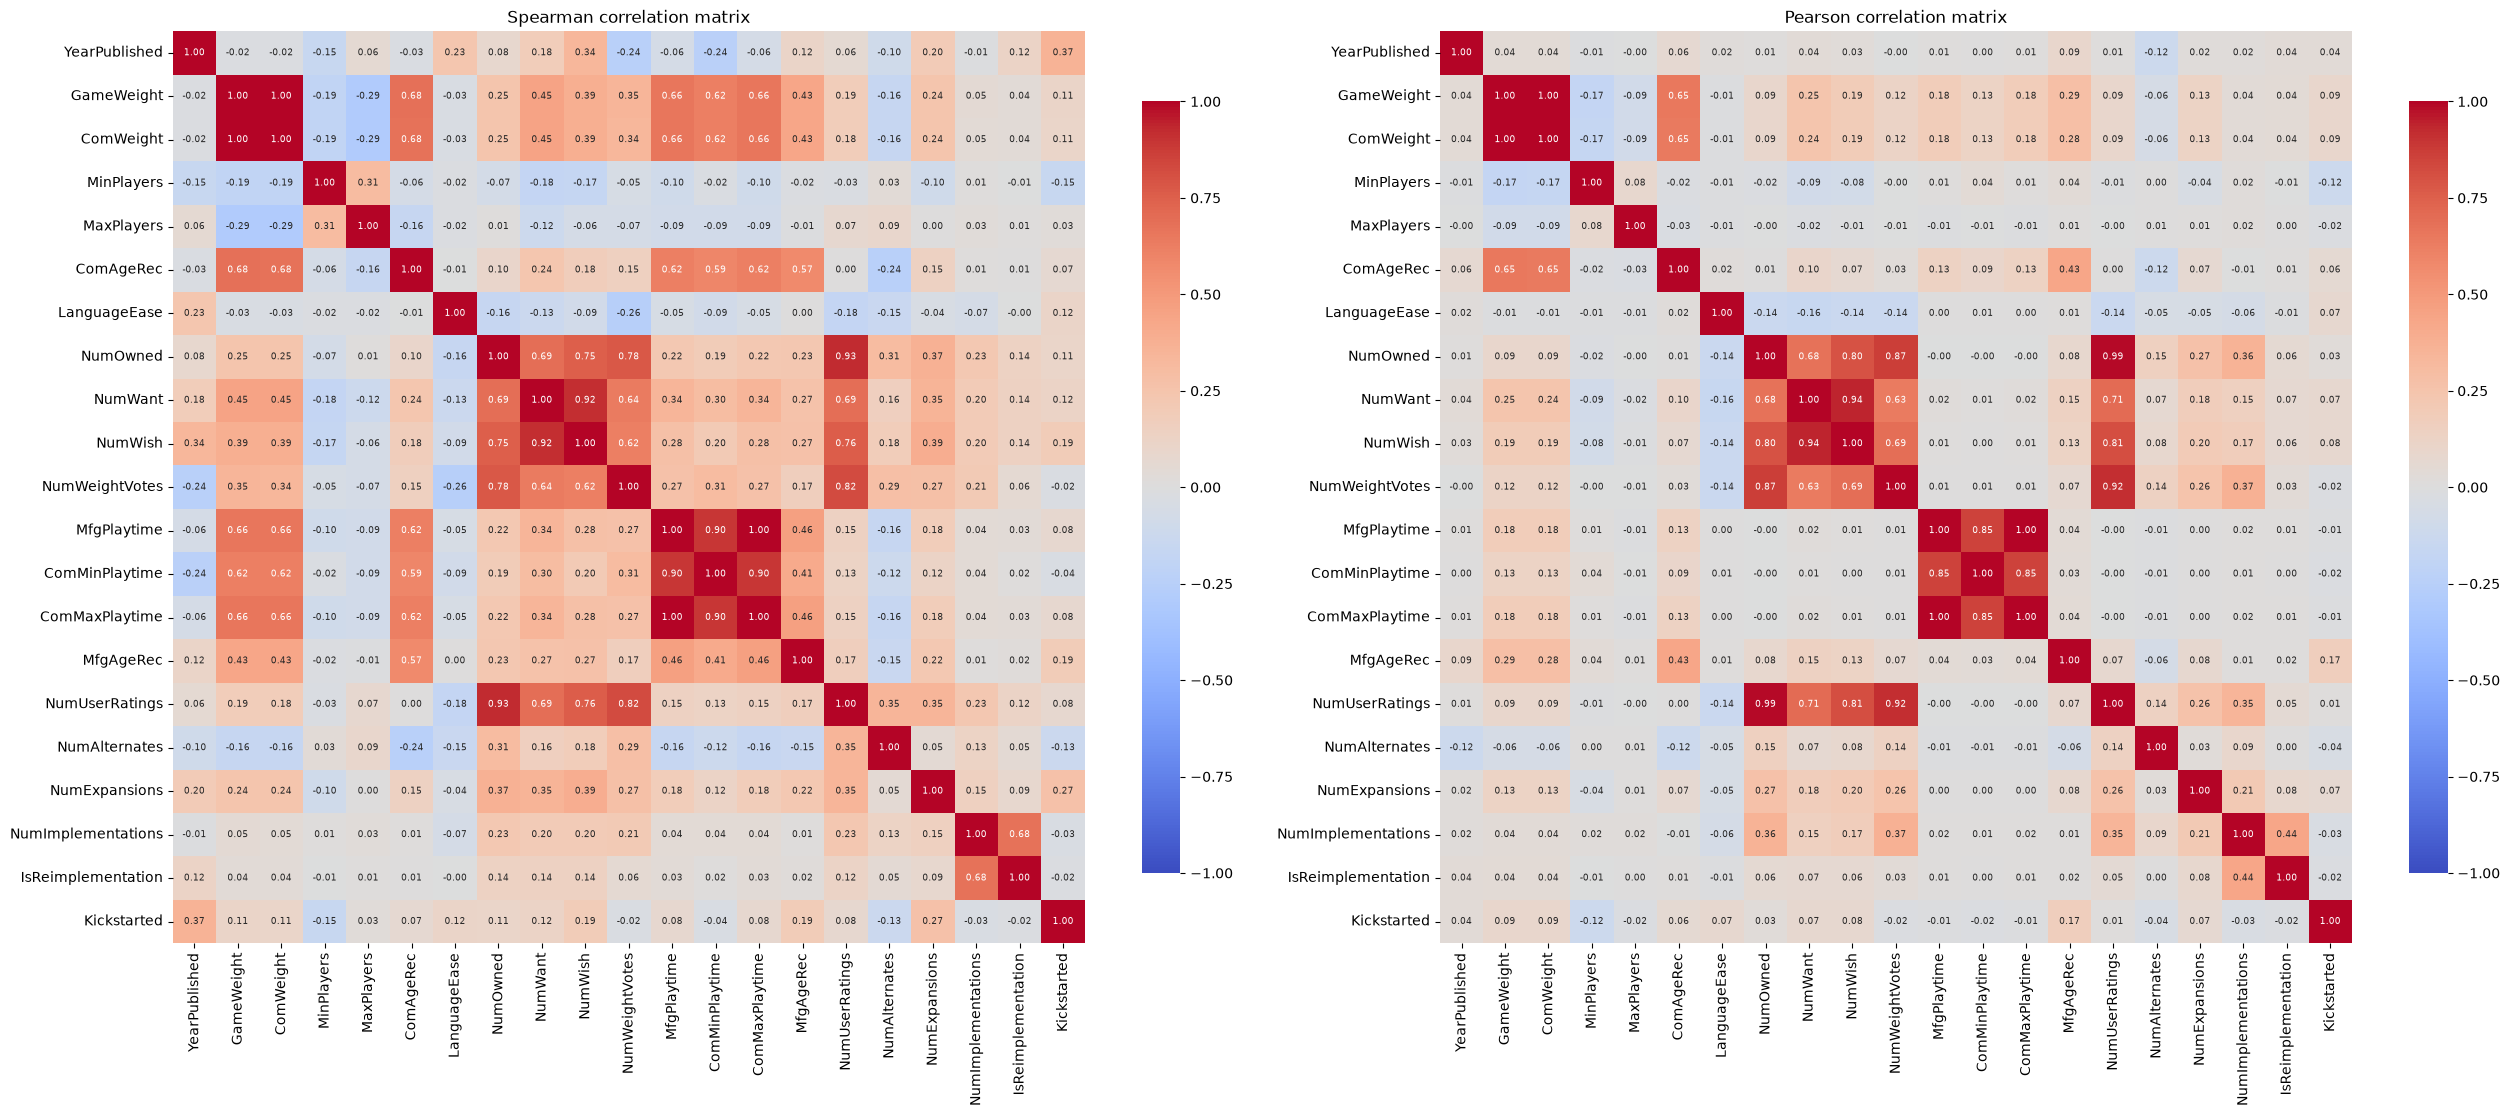

In [11]:
num_cols = ["YearPublished", "GameWeight", "ComWeight", "MinPlayers", "MaxPlayers",
            "ComAgeRec", "LanguageEase", "NumOwned", "NumWant", "NumWish",
            "NumWeightVotes", "MfgPlaytime", "ComMinPlaytime", "ComMaxPlaytime",
            "MfgAgeRec", "NumUserRatings", "NumAlternates", "NumExpansions",
            "NumImplementations", "IsReimplementation", "Kickstarted"]

pearson = df[num_cols].corr("pearson")
spearman = df[num_cols].corr("spearman")

fig, axes = plt.subplots(1, 2, figsize=(26, 11))
for ax, mat, name in [(axes[0], spearman, "Spearman"), (axes[1], pearson, "Pearson")]:
    sns.heatmap(mat, cmap="coolwarm", vmin=-1, vmax=1, annot=True, fmt=".2f",
                annot_kws={"size": 6.5}, square=True, ax=ax, cbar_kws={"shrink": .8})
    ax.set_title(f"{name} correlation matrix")
plt.tight_layout()
plt.show()

In [12]:
pairs = [(f"{a} - {b}", spearman.loc[a, b], pearson.loc[a, b])
         for i, a in enumerate(num_cols) for b in num_cols[i + 1:]
         if max(abs(spearman.loc[a, b]), abs(pearson.loc[a, b])) >= 0.60]
(pd.DataFrame(pairs, columns=["pair", "spearman", "pearson"])
   .sort_values("spearman", key=abs, ascending=False)
   .round(2).reset_index(drop=True))

,pair,spearman,pearson
0,MfgPlaytime - ComMaxPlaytime,1.00,1.00
1,GameWeight - ComWeight,1.00,1.00
2,NumOwned - NumUserRatings,0.93,0.99
3,NumWant - NumWish,0.92,0.94
4,ComMinPlaytime - ComMaxPlaytime,0.90,0.85
5,MfgPlaytime - ComMinPlaytime,0.90,0.85
6,NumWeightVotes - NumUserRatings,0.82,0.92
7,NumOwned - NumWeightVotes,0.78,0.87
8,NumWish - NumUserRatings,0.76,0.81
9,NumOwned - NumWish,0.75,0.80


`MfgPlaytime`-`ComMaxPlaytime` and `GameWeight`-`ComWeight` are perfect
duplicates. The popularity counts (`NumOwned`, `NumWish`, `NumWant`,
`NumUserRatings`, `NumWeightVotes`) form a strongly correlated block, and
complexity is associated with the community age recommendation and playtime.
This redundancy will guide the preparation phase.

## 1.4 Outlier search and distribution of key attributes

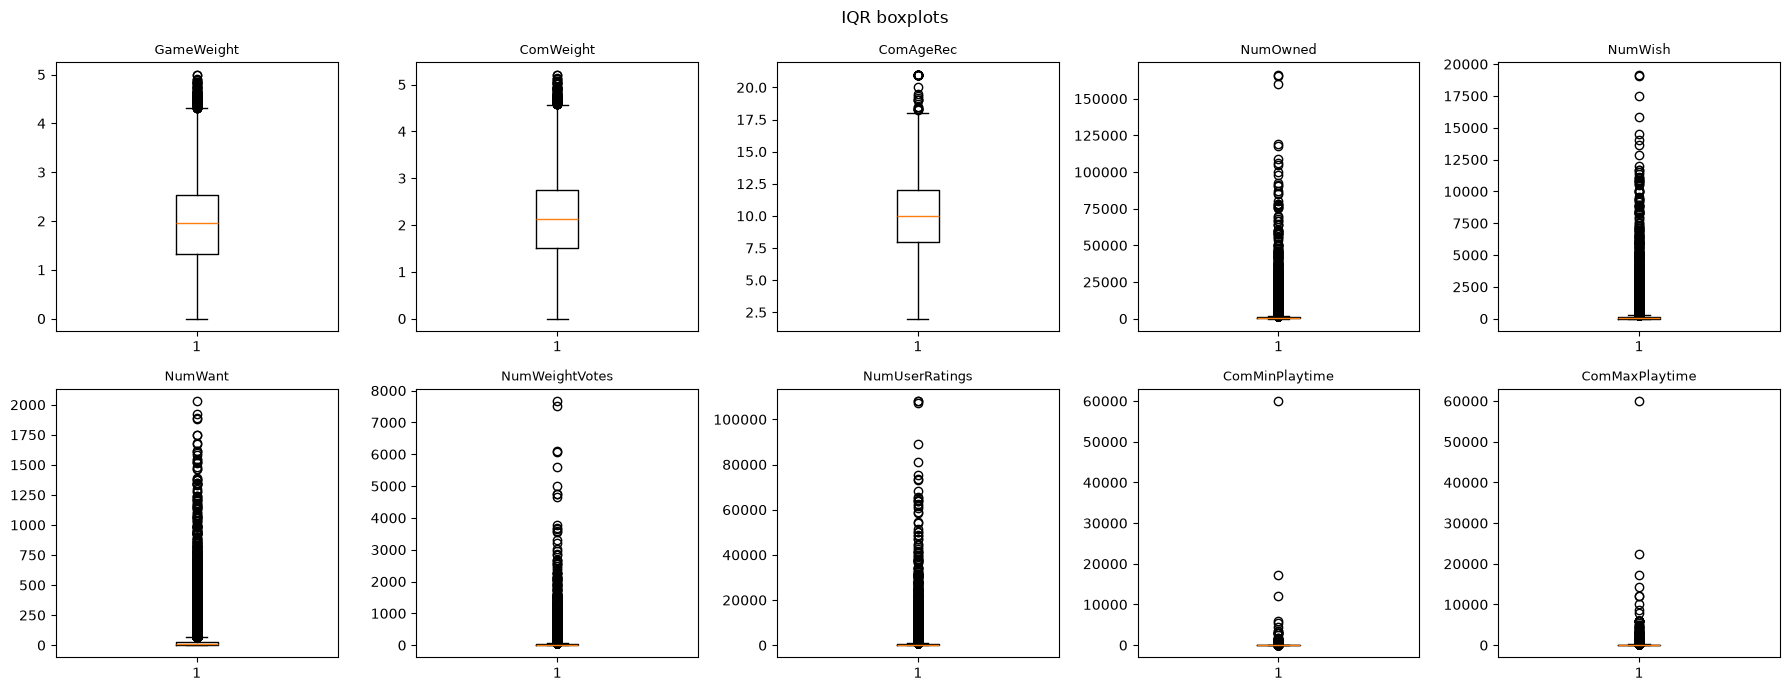

In [13]:
key_cols = ["GameWeight", "ComWeight", "ComAgeRec", "NumOwned", "NumWish",
            "NumWant", "NumWeightVotes", "NumUserRatings",
            "ComMinPlaytime", "ComMaxPlaytime"]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), key_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=9)
fig.suptitle("IQR boxplots")
plt.tight_layout()
plt.show()

In [14]:
rows = []
for col in key_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    W, p = stats.shapiro(s.sample(min(5000, len(s)), random_state=42))
    rows.append([col, out, out / len(s), stats.skew(s), stats.kurtosis(s), p])
pd.DataFrame(rows, columns=["attribute", "IQR outliers", "outlier frac",
                            "skewness", "kurtosis", "shapiro p"]).round(3)

,attribute,IQR outliers,outlier frac,skewness,kurtosis,shapiro p
0,GameWeight,134,0.006,0.396,0.053,0.0
1,ComWeight,100,0.005,0.303,0.209,0.0
2,ComAgeRec,41,0.003,0.144,-0.382,0.0
3,NumOwned,2845,0.130,12.517,238.574,0.0
4,NumWish,3030,0.138,9.350,124.364,0.0
5,NumWant,2910,0.133,6.956,65.822,0.0
6,NumWeightVotes,2938,0.134,15.316,366.233,0.0
7,NumUserRatings,3110,0.142,12.586,231.508,0.0
8,ComMinPlaytime,1711,0.078,116.199,15286.312,0.0
9,ComMaxPlaytime,1463,0.067,74.734,7728.803,0.0


The popularity counts contain a huge number of extreme values: a few very
famous games concentrate most of the community attention. Shapiro-Wilk rejects
normality everywhere (p ~ 0), mostly because of the strong positive skew and
extreme kurtosis; only `GameWeight`, `ComWeight` and `ComAgeRec` are reasonably
symmetric. For the right-skewed variables we check how much a `log1p`
transformation helps.

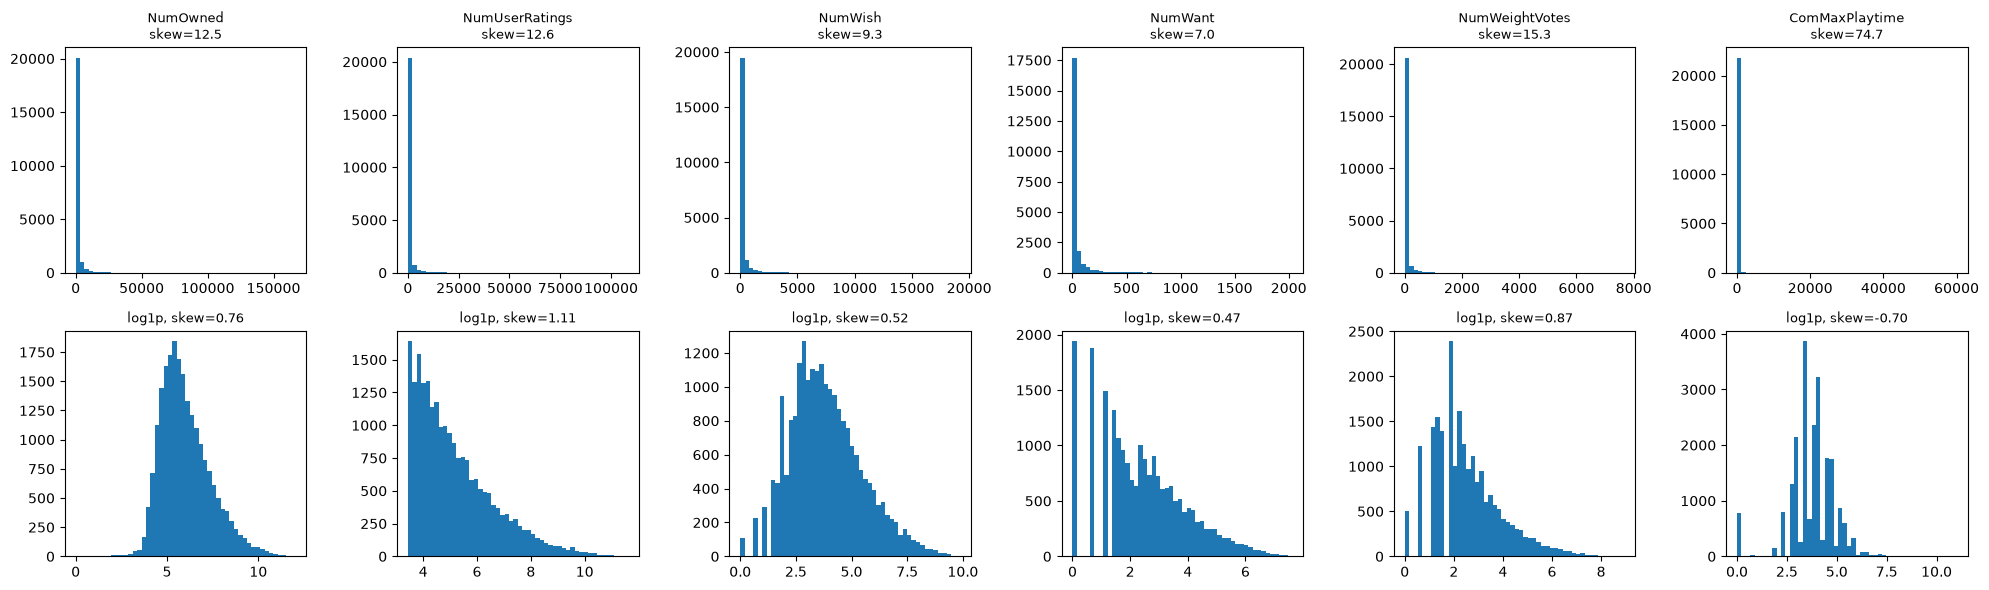

In [15]:
skewed = ["NumOwned", "NumUserRatings", "NumWish", "NumWant",
          "NumWeightVotes", "ComMaxPlaytime"]

fig, axes = plt.subplots(2, 6, figsize=(20, 6))
for j, col in enumerate(skewed):
    s = df[col].dropna()
    axes[0, j].hist(s, bins=50)
    axes[0, j].set_title(f"{col}\nskew={stats.skew(s):.1f}", fontsize=9)
    axes[1, j].hist(np.log1p(s), bins=50)
    axes[1, j].set_title(f"log1p, skew={stats.skew(np.log1p(s)):.2f}", fontsize=9)
plt.tight_layout()
plt.show()

The transformation removes most of the asymmetry, so log-transformed versions
of these variables will be used in the following modules.

Finally, the prevalence of the binary flags: categories are quite unbalanced
and a game can belong to several categories at once (multi-label).

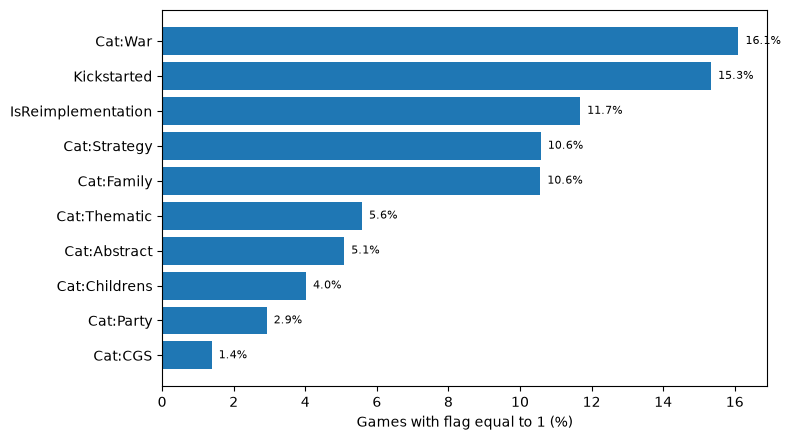

In [16]:
bin_cols = CAT_COLS + ["Kickstarted", "IsReimplementation"]
prev = (df[bin_cols].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(prev.index, prev.values)
for y, v in enumerate(prev.values):
    ax.text(v + .2, y, f"{v:.1f}%", va="center", fontsize=8)
ax.set_xlabel("Games with flag equal to 1 (%)")
plt.tight_layout()
plt.show()